In [125]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime

In [126]:
my_file = open("dataRaw_21-02-2023-18_08_47oe2el.txt", "r")
  
# reading the file
oe2el_local = my_file.read()
oe2el_local_list = oe2el_local.split("\n")
print(len(oe2el_local_list))
A = [float(x) for x in oe2el_local_list]

2670


In [127]:
my_file = open("dataRaw_21-02-2023-18_47_05oe2el.txt", "r")
  
# reading the file
oe2el_remote = my_file.read()
oe2el_remote_list = oe2el_remote.split("\n")
print(len(oe2el_remote_list))
B = [float(x) for x in oe2el_remote_list]

2921


In [128]:
if len(B)> len(A):
    print("change B size")
    B=B[:len(A)]

else:
    print("change A size")
    A=A[:len(B)]
 

df = pd.DataFrame(
    {'Local Execution': A,
     'Edge Execution': B
    })
    



change B size


{'whiskers': [<matplotlib.lines.Line2D at 0x1dd9cccfe80>,
 'caps': [<matplotlib.lines.Line2D at 0x1dd9cccf820>,
 'boxes': [<matplotlib.lines.Line2D at 0x1dd9cccf100>],
 'medians': [<matplotlib.lines.Line2D at 0x1dd9bb53cd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1dd9ccc3ac0>],
 'means': [<matplotlib.lines.Line2D at 0x1dd9ccc35e0>]}

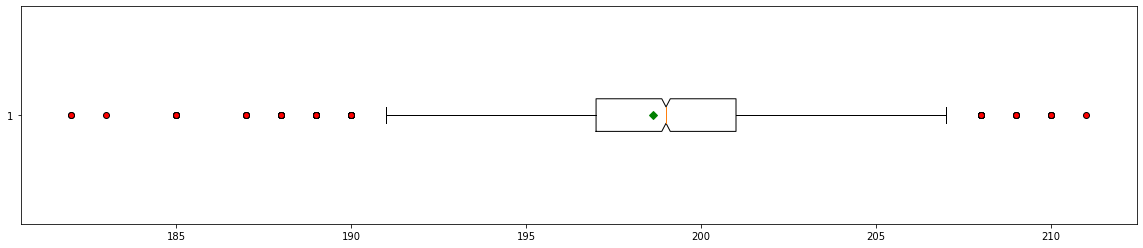

In [129]:
#Simple boxplot using pandas

plt.rcParams['figure.figsize'] = [20, 4]
red_circle = dict(markerfacecolor='red', marker='o')

mean_shape = dict(markerfacecolor='green', marker='D', markeredgecolor='green')
plt.boxplot(x=df['Edge Execution'], vert=False, flierprops=red_circle,showmeans=True, meanprops=mean_shape, notch=True)

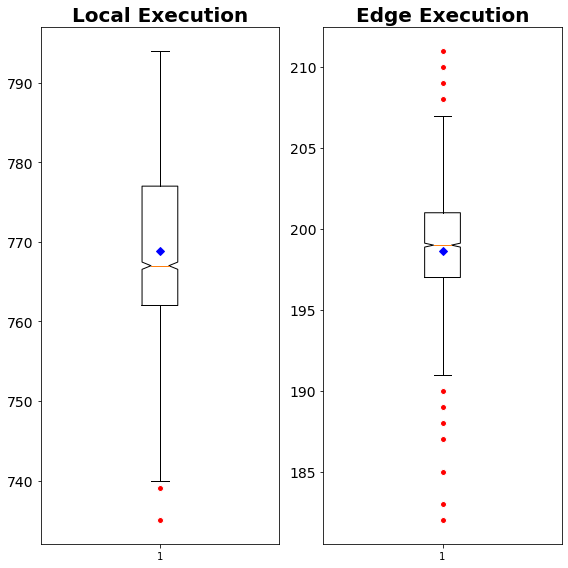

In [130]:
#Creating subplot of each column with its own scale
red_circle = dict(markerfacecolor='red', marker='o', markeredgecolor='white')
mean_shape = dict(markerfacecolor='blue', marker='D', markeredgecolor='blue')
fig, axs = plt.subplots(1, len(df.columns), figsize=(8,8))

for i, ax in enumerate(axs.flat):
    ax.boxplot(df.iloc[:,i], flierprops=red_circle,showmeans=True, meanprops=mean_shape, notch=True, vert=True)
    ax.set_title(df.columns[i], fontsize=20, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    
plt.tight_layout()

In [131]:
def drawCDF(data,data2, bins_x=10):
    count, bins_count = np.histogram(data, bins=bins_x)
    
    # finding the PDF of the histogram using count values
    pdf = count / sum(count)
    
    # using numpy np.cumsum to calculate the CDF
    # We can also find using the PDF values by looping and adding
    cdf = np.cumsum(pdf)
    
    count2, bins_count2 = np.histogram(data2, bins=bins_x)
    
    # finding the PDF of the histogram using count values
    pdf2 = count2 / sum(count2)
    
    # using numpy np.cumsum to calculate the CDF
    # We can also find using the PDF values by looping and adding
    cdf2 = np.cumsum(pdf2)



    # plotting PDF and CDF
    plt.rcParams['figure.figsize'] = [20, 4]
    plt.plot(bins_count[1:], cdf, color="red", label="CDF1")
    plt.plot(bins_count2[1:], cdf, color="blue", label="CDF2")
    plt.legend()





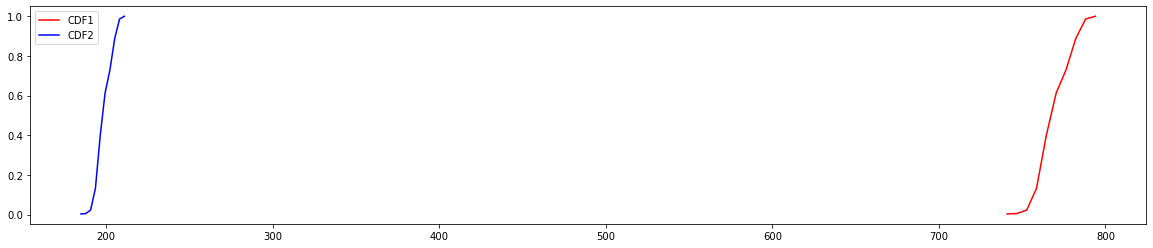

In [132]:
drawCDF(A,B, bins_x=10)